(lecture06:homework)=
# Homework 6

+ Type your name and email in the "Student details" section below.
+ Develop the code and generate the figures you need to solve the problems using this notebook.
+ For the answers that require a mathematical proof or derivation you can either:
    
    - Type the answer using the built-in latex capabilities. In this case, simply export the notebook as a pdf and upload it on gradescope; or
    - You can print the notebook (after you are done with all the code), write your answers by hand, scan, turn your response to a single pdf, and upload on gradescope.

+ The total homework points are 100. Please note that the problems are not weighed equally.

```{note}
+ Please match all the pages corresponding to each of the questions when you submit on gradescope.
```

## Student details

+ **First Name:** Timothy
+ **Last Name:** Lee
+ **Email:** lee5695@purdue.edu

In [25]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set(rc={"figure.dpi":100, 'savefig.dpi':300})
sns.set_context('notebook')
sns.set_style("ticks")
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina', 'svg')
import requests
import os
def download(url, local_filename=None):
    """
    Downloads the file in the ``url`` and saves it in the current working directory.
    """
    data = requests.get(url)
    if local_filename is None:
        local_filename = os.path.basename(url)
    with open(local_filename, 'wb') as fd:
        fd.write(data.content)

/tmp/ipython-input-368/1846507495.py:8: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina', 'svg')


## Problem 1 - Loops and conditionals

Consider the following list:

In [1]:
data = [1, 4, 3, 10, 4, 3, 4, 4]

+ Write a loop that computes the average of the elements in the list and ``print`` the result using two significant digits.

In [6]:
total = 0
for i in data:
  total += i
average = total / len(data)
print(f'{average:.2g}')

4.1


+ Write code that finds the number of times the element 4 occurs in the list. Hint: Use a loop and an if-statement.

In [7]:
counter = 0
for i in data:
  if i == 4:
    counter += 1
print(counter)

4


+ Write a Python function that takes a list as an argument and returns the number of times a given element (also passed as an argument to the function) appears in the list. Call that function ``find_number_of_occurences(a, elm)``. Make sure you follow best practices when writing the docstring of your function.

In [17]:
def find_number_of_occurences(a, elm):
  """
  Returns the number of times an element exists in a list as an integer.

  Arguments:

  a    -   the list that is passed in and searched through.
  elm  -   the element that is being searched for and counted in the list.

  Returns:

  occurrences  -   the number of times the element appeared in the list.
  """
  occurrences = 0
  for i in a:
    if i == elm:
      occurrences += 1
  return int(occurrences)

In [18]:
# Try your code here:
help(find_number_of_occurences)

Help on function find_number_of_occurences in module __main__:

find_number_of_occurences(a, elm)
    Returns the number of times an element exists in a list as an integer.

    Arguments:

    a    -   the list that is passed in and searched through.
    elm  -   the element that is being searched for and counted in the list.

    Returns:

    occurrences  -   the number of times the element appeared in the list.



In [19]:
# Try your code here:
find_number_of_occurences(data, 4)

4

+ Write a Python function that takes a list as an argument and returns the number of elements that are greater than a given element (also passed as an argument to the function). Call that function ``find_number_of_elms_greater_than(a, elm)``. Make sure you follow best practices when writing the docstring of your function.

In [21]:
def find_number_of_elms_greater_than(a, elm):
  """
  Returns the number of elements greater than an element in a list as an integer.

  Arguments:

  a    -   the list that is passed in and searched through.
  elm  -   the element that is being searched for and compared to in the list.

  Returns:

  greaterthan  -   the number of times an element in the list was greater than the given element.
  """
  greaterthan = 0
  for i in a:
    if i > elm:
      greaterthan += 1
  return int(greaterthan)

In [22]:
# Try your code here:
help(find_number_of_elms_greater_than)

Help on function find_number_of_elms_greater_than in module __main__:

find_number_of_elms_greater_than(a, elm)
    Returns the number of elements greater than an element in a list as an integer.

    Arguments:

    a    -   the list that is passed in and searched through.
    elm  -   the element that is being searched for and compared to in the list.

    Returns:

    greaterthan  -   the number of times an element in the list was greater than the given element.



In [23]:
# Try your code here:
find_number_of_elms_greater_than(data, 3)

5

## Problem 2 - High-performance buildings revisited

In this problem we will continue analyzing the high-performance buildings dataset we introduced in {ref}`lecture03:homework:problem1` and with which we played in {ref}`lecture06:selecting-rows`.
Let me set you up by downloading and cleaning the data file:

In [27]:
!curl -O 'https://raw.githubusercontent.com/PurdueMechanicalEngineering/me-239-intro-to-data-science/master/data/temperature_raw.xlsx'

import pandas as pd

df = pd.read_excel('temperature_raw.xlsx')
df = df.dropna(axis=0)
df.date = pd.to_datetime(df['date'], format='%Y-%m-%d')
df.head()

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  277k  100  277k    0     0  1255k      0 --:--:-- --:--:-- --:--:-- 1263k


,household,date,score,t_out,t_unit,hvac
0,a1,2018-01-07,100.0,4.283373,66.693229,246.473231
1,a10,2018-01-07,100.0,4.283373,66.356134,5.492116
2,a11,2018-01-07,58.0,4.283373,71.549132,402.094327
3,a12,2018-01-07,64.0,4.283373,73.429514,211.692244
4,a13,2018-01-07,100.0,4.283373,63.923937,0.850536


+ Plot the external temperature `t_out`

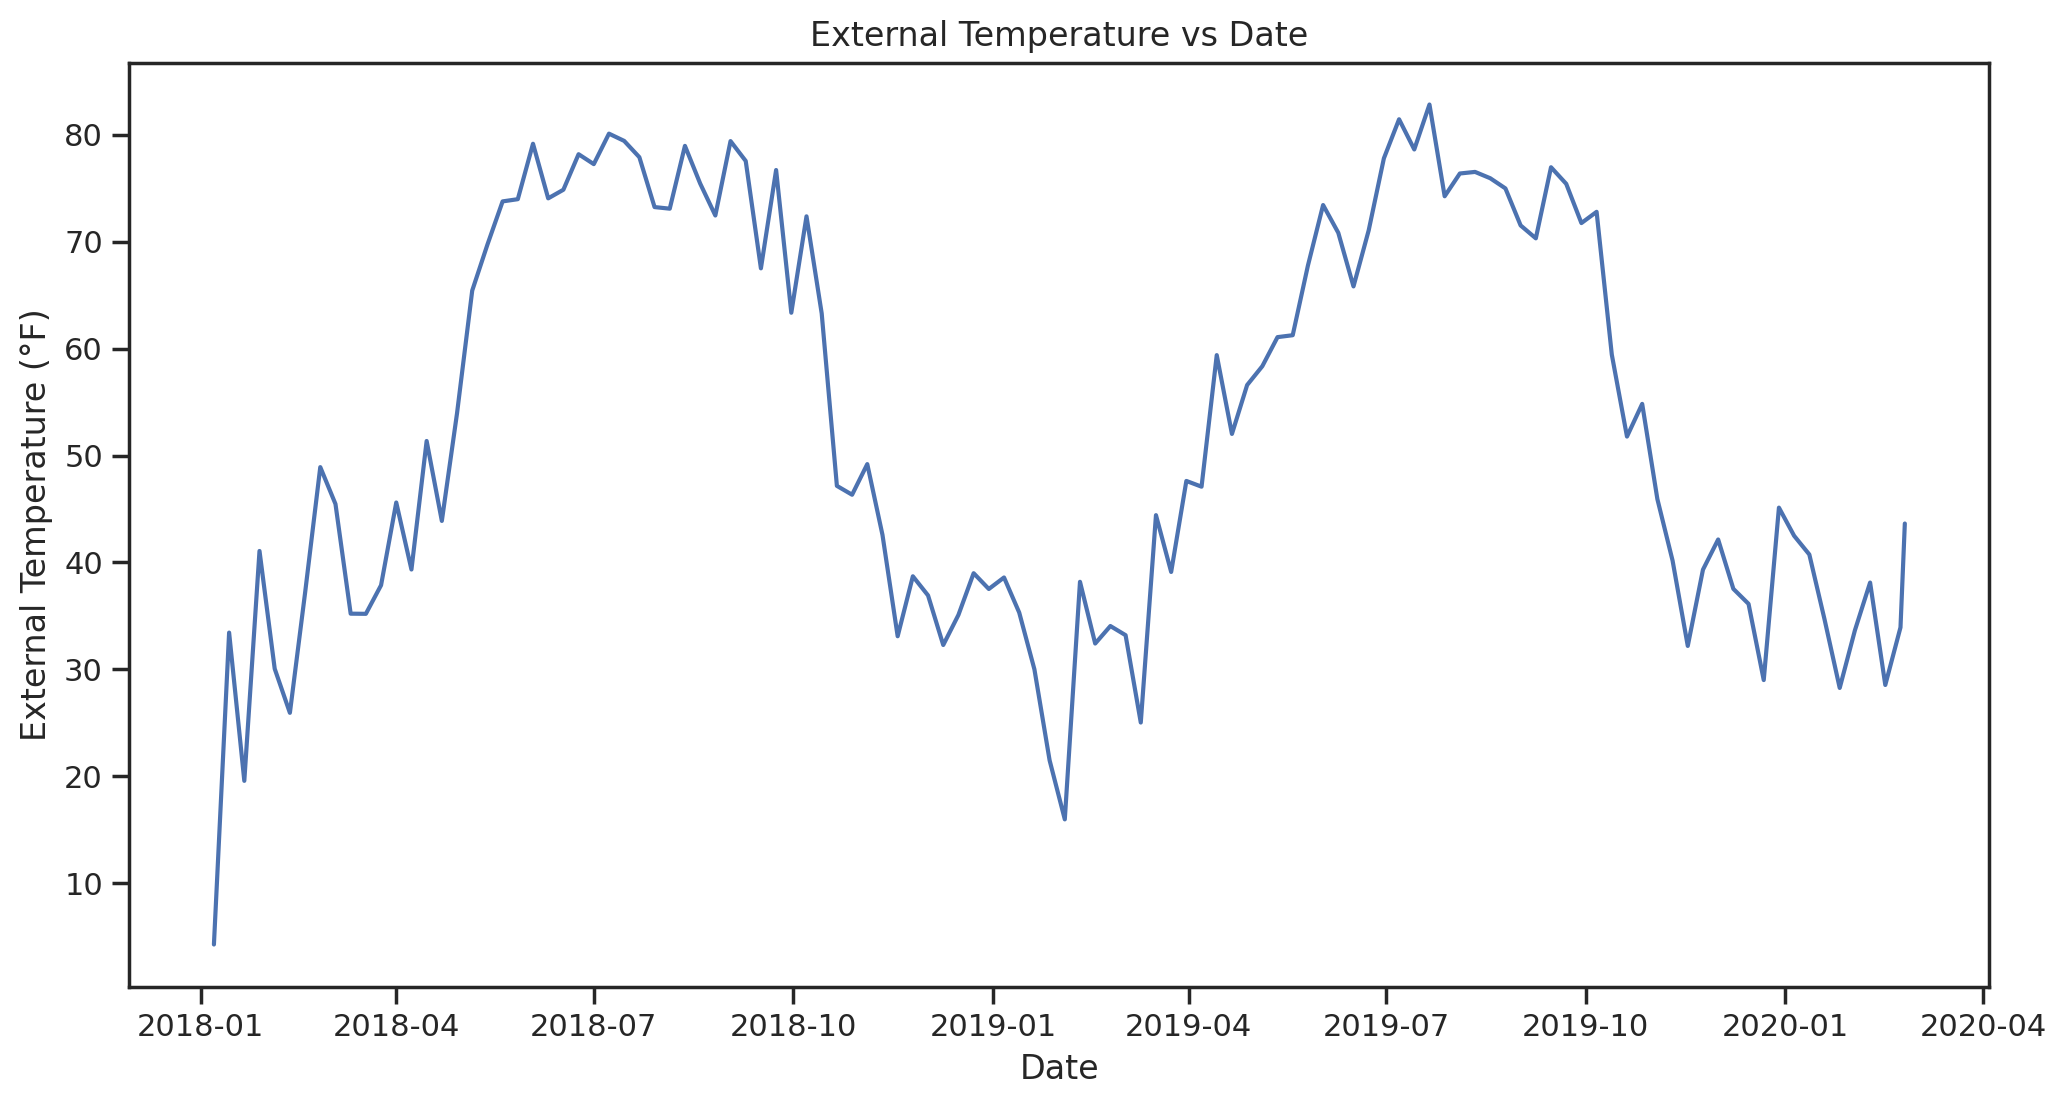

In [40]:
plt.figure(figsize=(12,6))
plt.plot(df['date'], df['t_out'])
plt.xlabel('Date')
plt.ylabel('External Temperature (°F)')
plt.title('External Temperature vs Date')
plt.show()

+ Extract the data pertaining to household `a5`.
Put the result in a new dataframe called `df_a5`.

In [36]:
df_a5 = df[df['household'] == 'a5']
df_a5.head()

,household,date,score,t_out,t_unit,hvac
11,a5,2018-01-07,64.0,4.283373,74.854456,286.011150
61,a5,2018-01-14,78.0,33.444172,74.786855,137.786711
111,a5,2018-01-21,67.0,19.584102,75.463740,229.760337
161,a5,2018-01-28,74.0,41.076513,75.382341,79.433718
211,a5,2018-02-04,64.0,30.065774,75.676811,118.032515


+ For household `a5`, plot `t_unit` as a function of date.

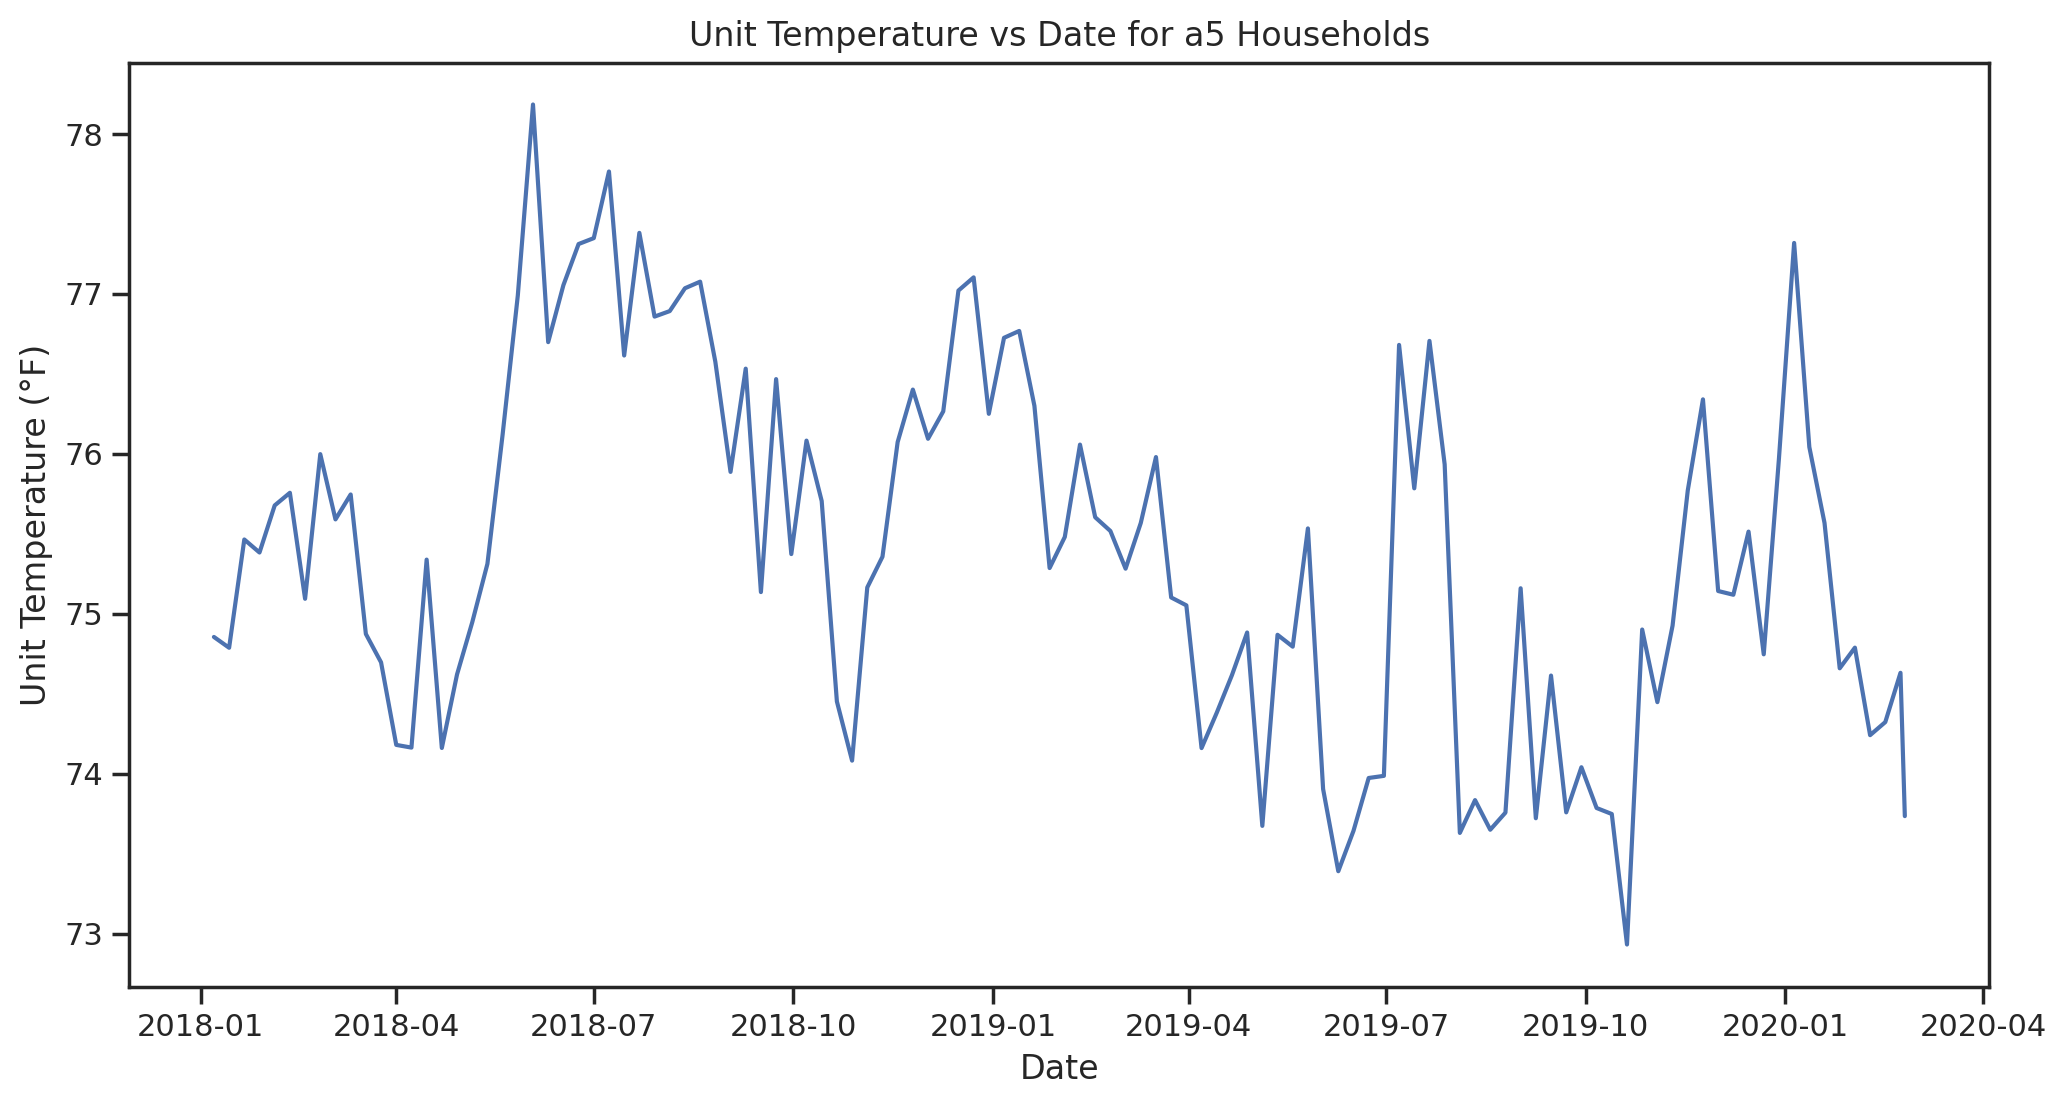

In [48]:
plt.figure(figsize=(12,6))
plt.plot(df_a5['date'], df_a5['t_unit'])
plt.xlabel('Date')
plt.ylabel('Unit Temperature (°F)')
plt.title('Unit Temperature vs Date for a5 Households')
plt.show()

+ In a single figure, plot `date` vs `t_unit` for households `a5` and `a11`.

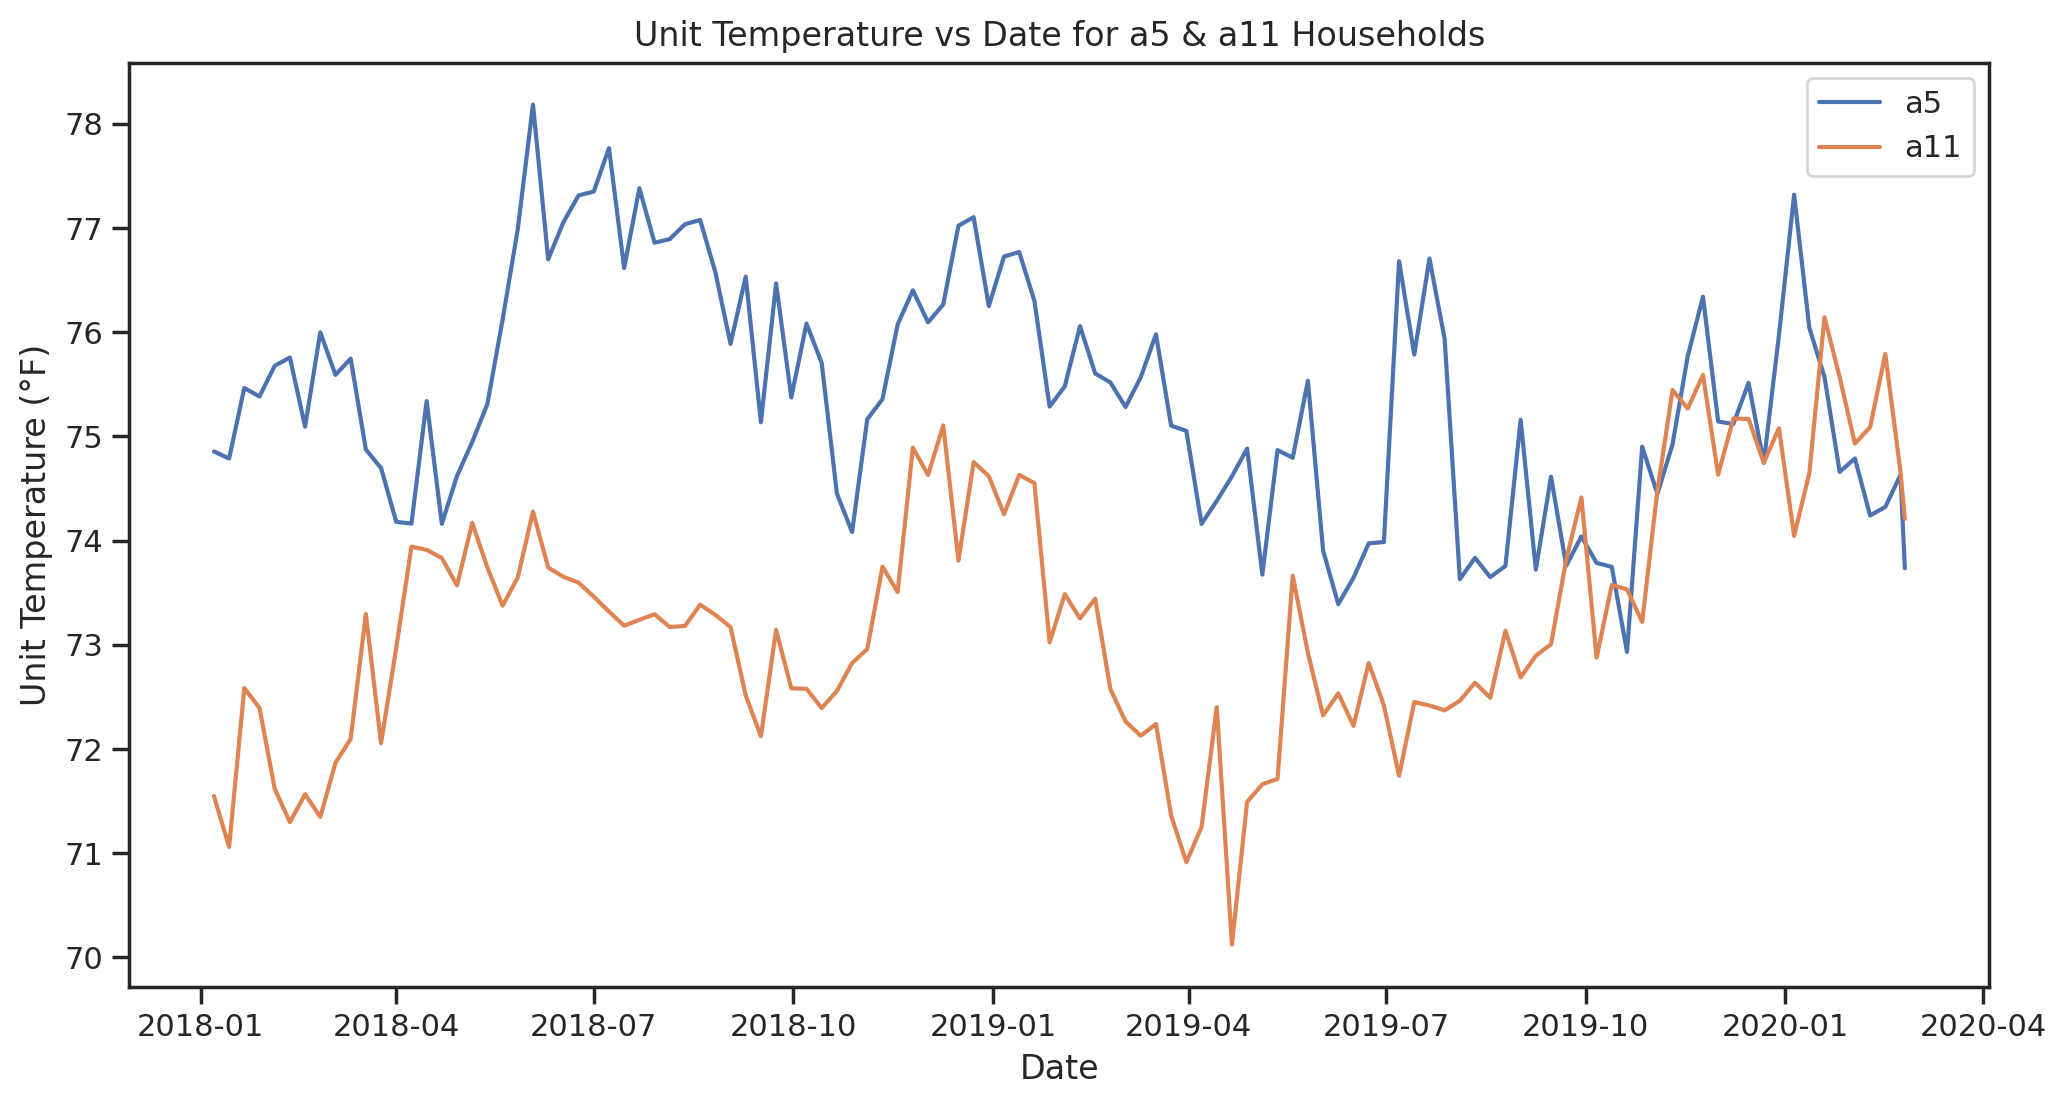

In [49]:
df_a11 = df[df['household'] == 'a11']

plt.figure(figsize=(12,6))
plt.plot(df_a5['date'], df_a5['t_unit'], label='a5')
plt.plot(df_a11['date'], df_a11['t_unit'], label='a11')
plt.xlabel('Date')
plt.ylabel('Unit Temperature (°F)')
plt.title('Unit Temperature vs Date for a5 & a11 Households')
plt.legend()
plt.show()

+ In the same figure, plot the `t_out` and `t_unit` scatter plots for both households `a5` and `a11`.

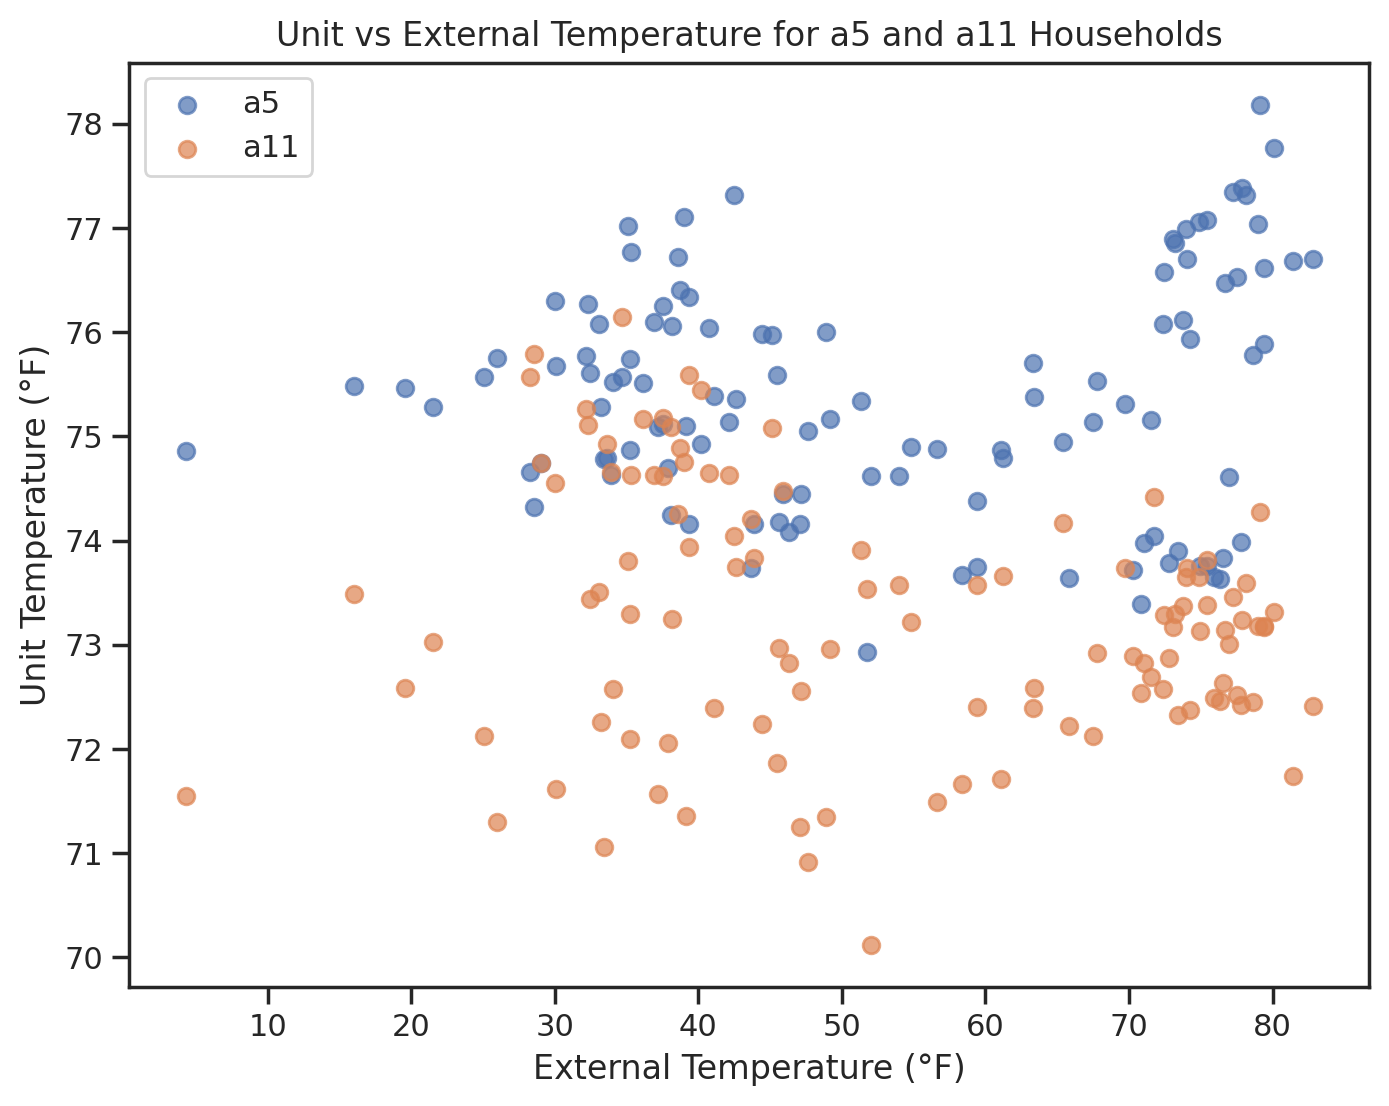

In [57]:
plt.figure(figsize=(8,6))
plt.scatter(df_a5['t_out'], df_a5['t_unit'], alpha=0.7, label='a5')
plt.scatter(df_a11['t_out'], df_a11['t_unit'], alpha=0.7, label='a11')
plt.xlabel('External Temperature (°F)')
plt.ylabel('Unit Temperature (°F)')
plt.title('Unit vs External Temperature for a5 and a11 Households')
plt.legend()
plt.show()

+ In the same figure, plot the `t_out` and `hvac` scatter plots for both households `a5` and `a11`.

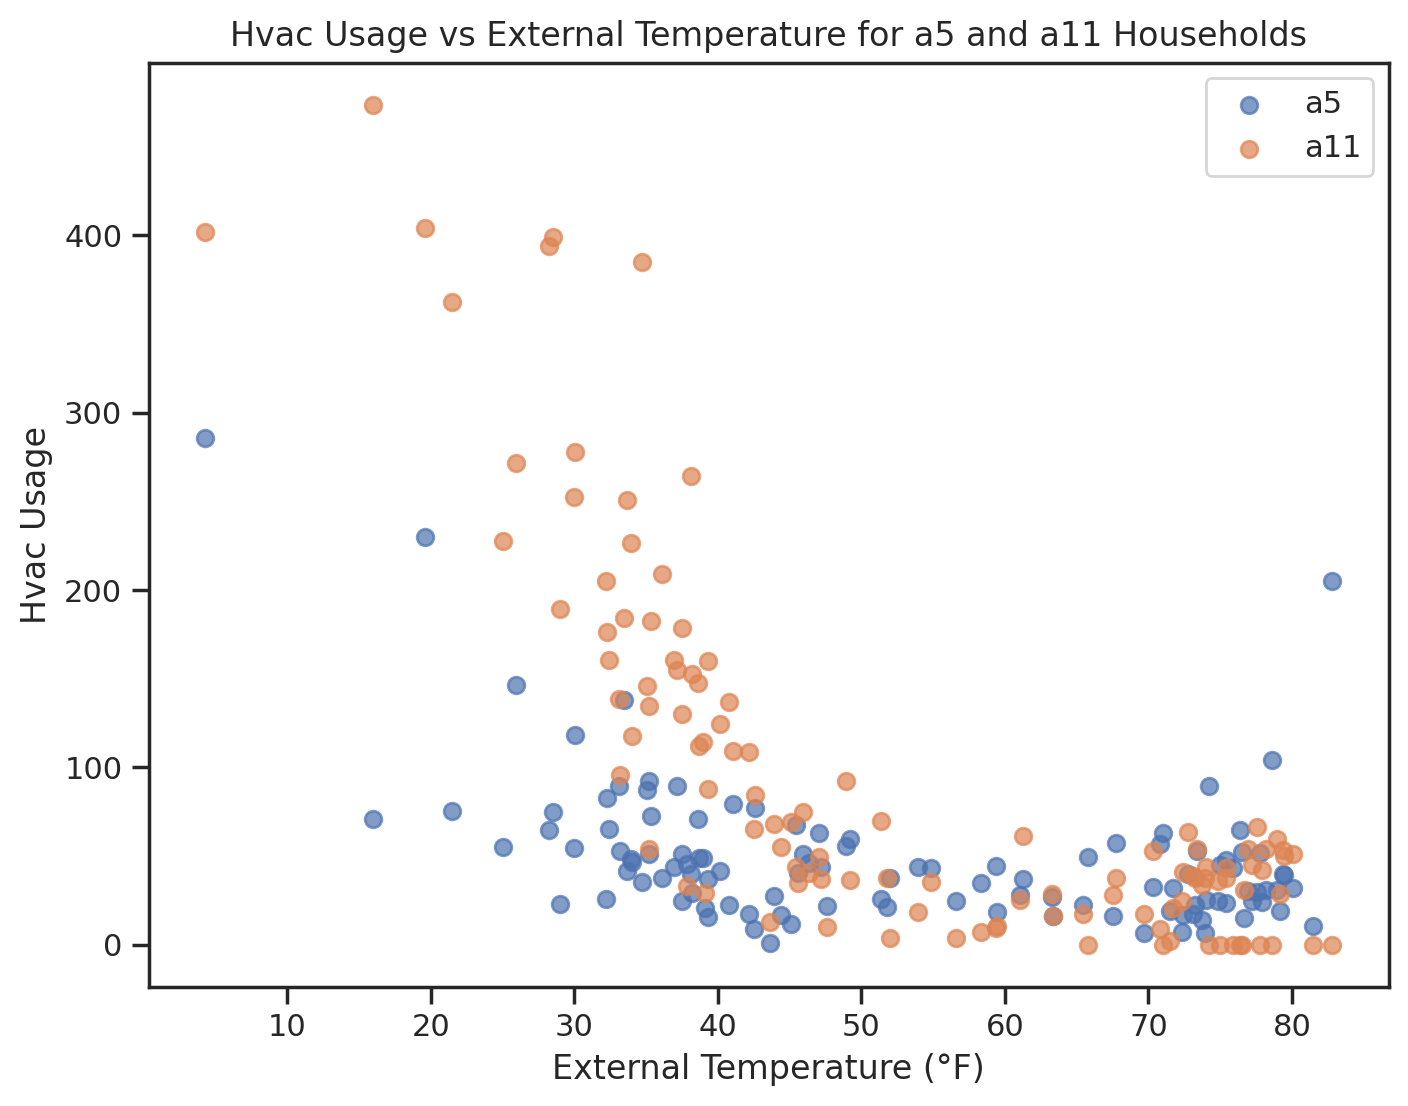

In [59]:
plt.figure(figsize=(8,6))
plt.scatter(df_a5['t_out'], df_a5['hvac'], alpha=0.7, label='a5')
plt.scatter(df_a11['t_out'], df_a11['hvac'], alpha=0.7, label='a11')
plt.xlabel('External Temperature (°F)')
plt.ylabel('Hvac Usage')
plt.title('Hvac Usage vs External Temperature for a5 and a11 Households')
plt.legend()
plt.show()

+ In the same figure, plot the histogram of `t_unit` for households `a5` and `a11`.
Which household prefers cooler temperatures?
Hint: To make the histogram more appealing use the keywords ``density=True, alpha=0.25``.

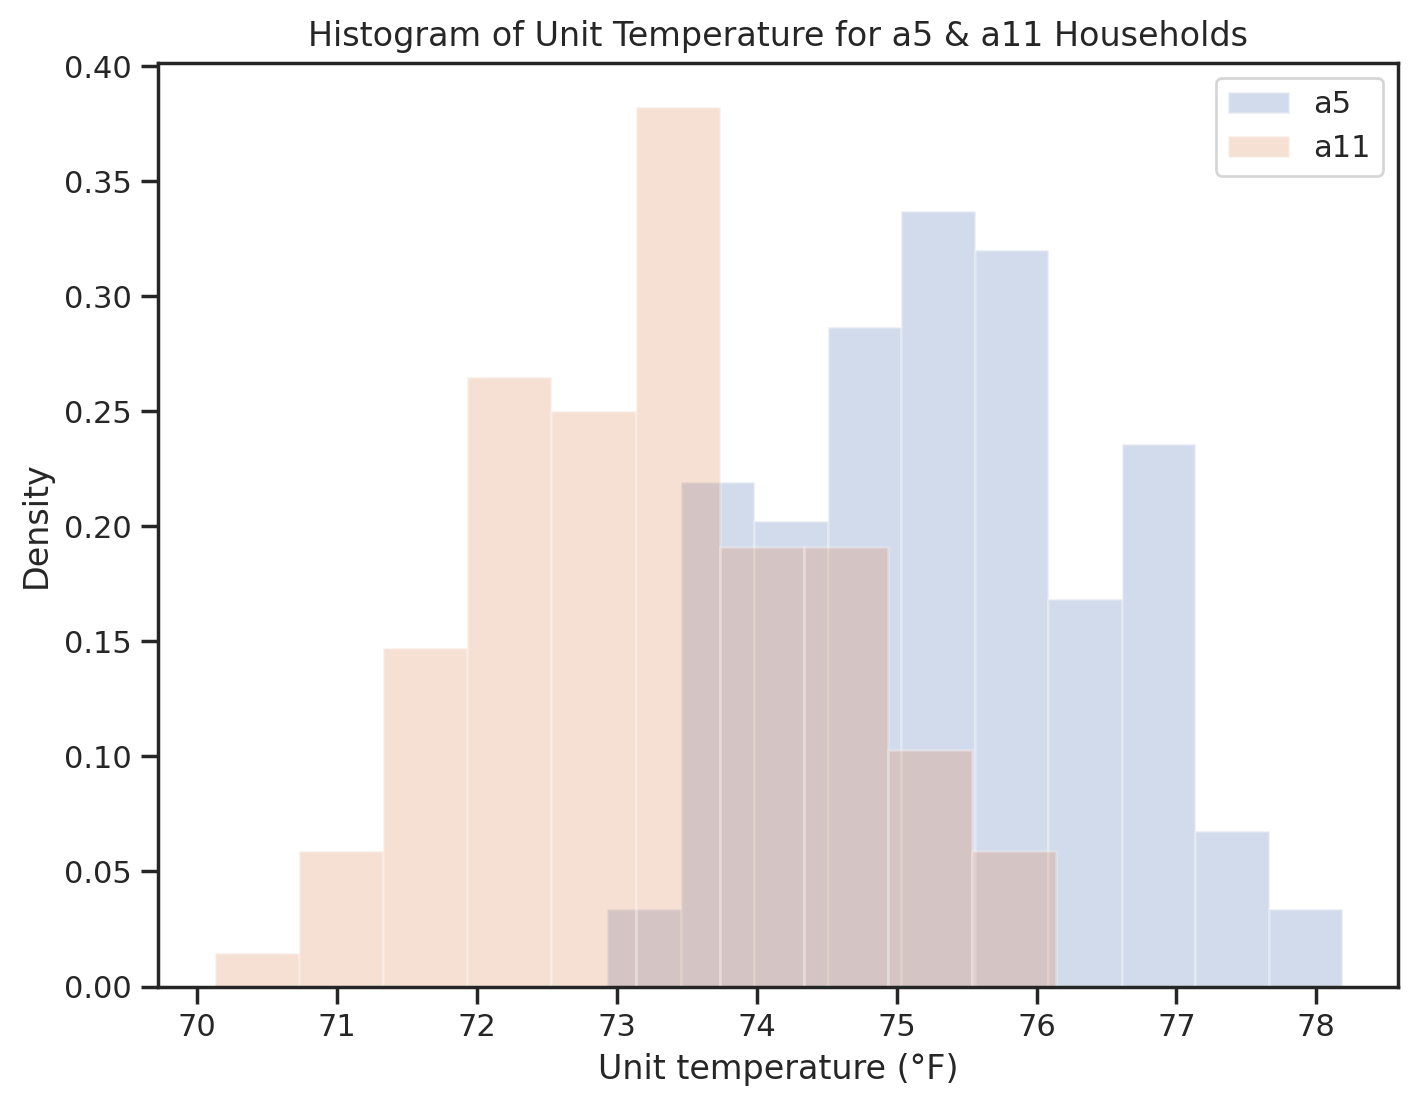

In [63]:
plt.figure(figsize=(8,6))
plt.hist(df_a5['t_unit'], density=True, alpha=0.25, label='a5')
plt.hist(df_a11['t_unit'], density=True, alpha=0.25, label='a11')

plt.xlabel('Unit temperature (°F)')
plt.ylabel('Density')
plt.title('Histogram of Unit Temperature for a5 & a11 Households')
plt.legend()
plt.show()

Households of the type a11 prefer cooler temperatures.

+ In the same figure, plot the histogram of `hvac` for households `a5` and `a11`.
Which household is more energy efficient (if any) and why?

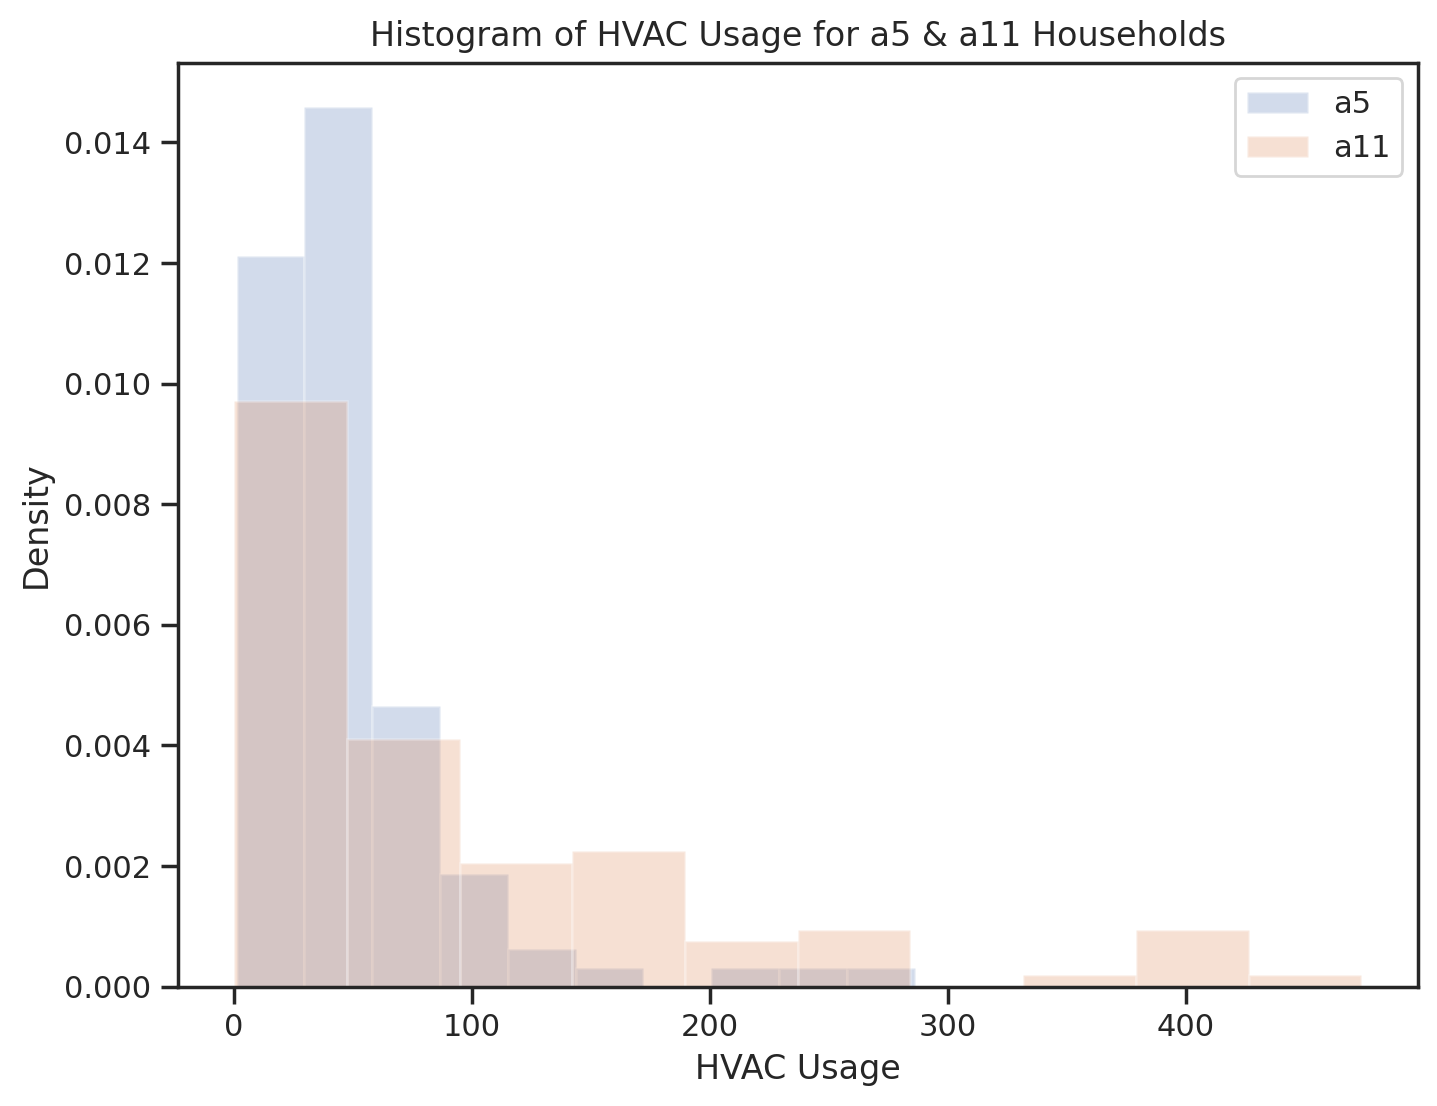

In [64]:
plt.figure(figsize=(8,6))
plt.hist(df_a5['hvac'], density=True, alpha=0.25, label='a5')
plt.hist(df_a11['hvac'], density=True, alpha=0.25, label='a11')
plt.xlabel('HVAC Usage')
plt.ylabel('Density')
plt.title('Histogram of HVAC Usage for a5 & a11 Households')
plt.legend()
plt.show()

Households of the type a5 are more energy efficient, as it is more clustered at lower values of HVAC usage than a11.

+ Repeat the analysis above for households `b17` and `c40`. Which household prefers cooler temperatures and which one is more energy efficient?

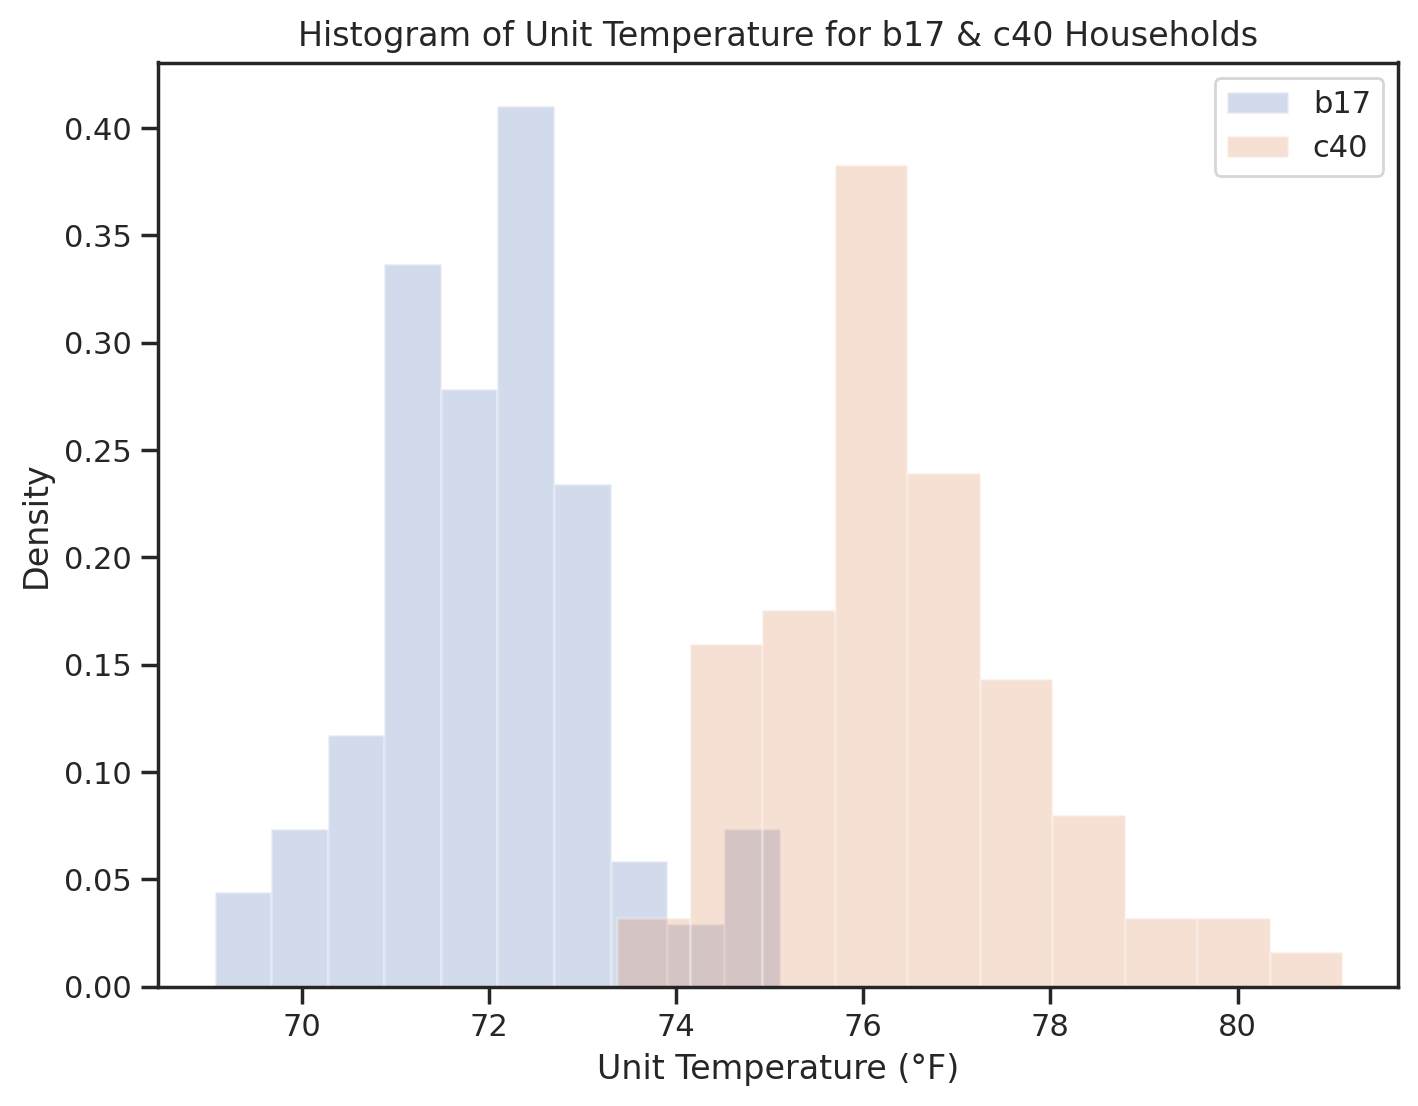

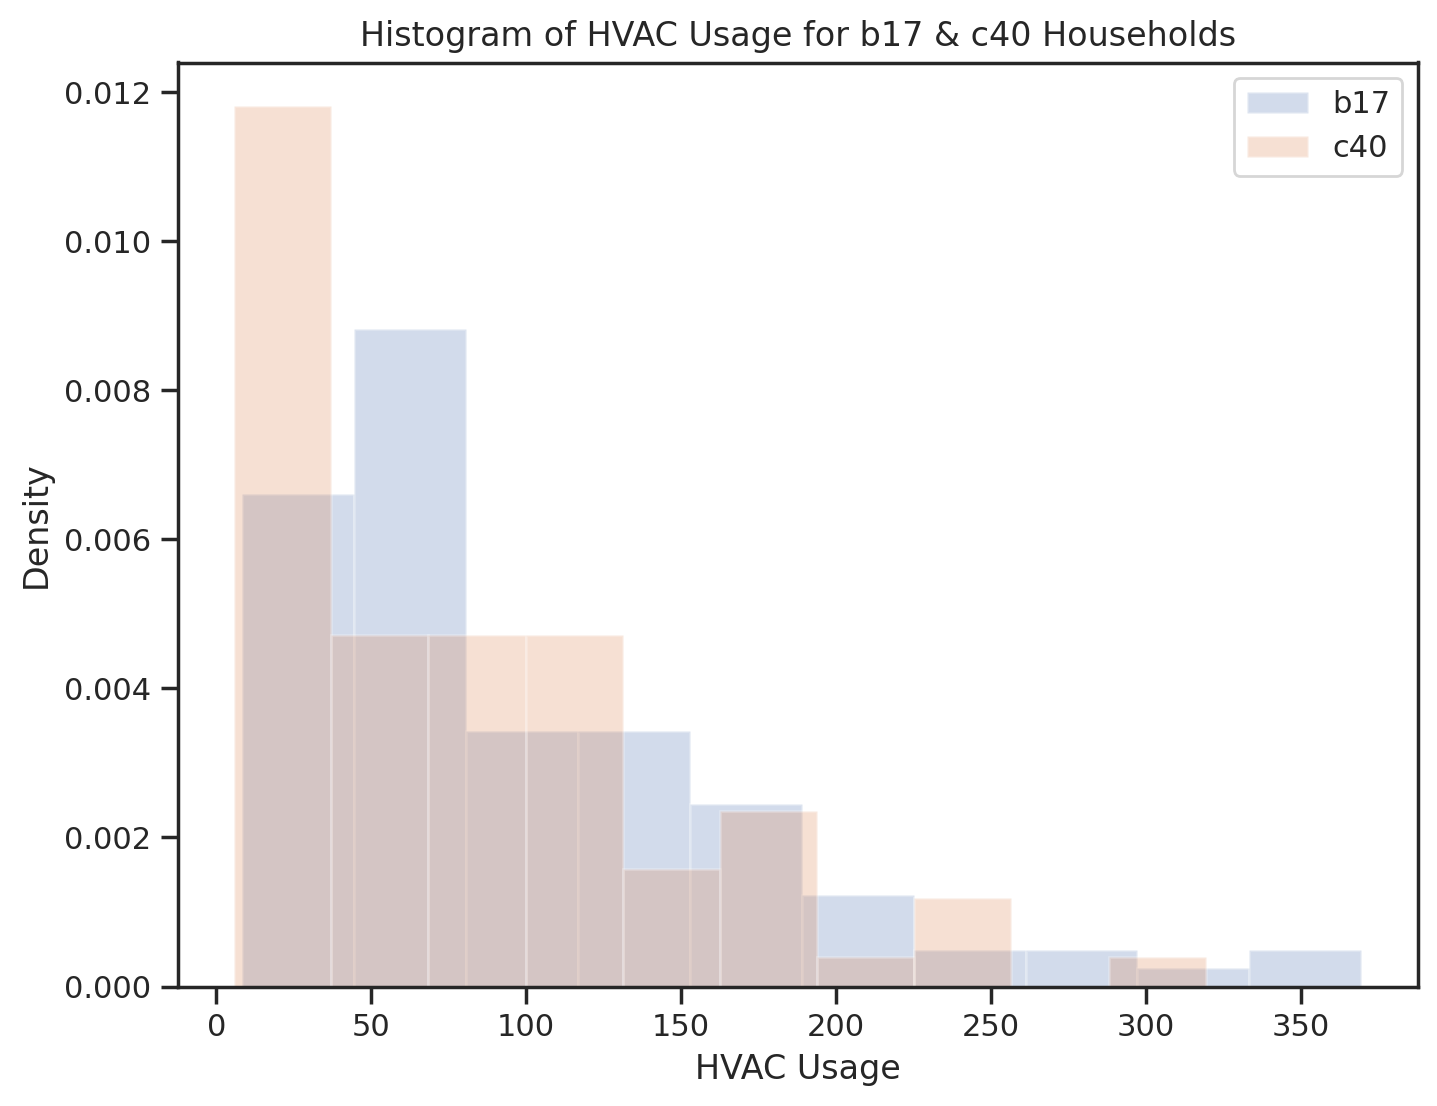

In [66]:
df_b17 = df[df['household'] == 'b17']
df_c40 = df[df['household'] == 'c40']

plt.figure(figsize=(8,6))
plt.hist(df_b17['t_unit'], density=True, alpha=0.25, label='b17')
plt.hist(df_c40['t_unit'], density=True, alpha=0.25, label='c40')
plt.xlabel('Unit Temperature (°F)')
plt.ylabel('Density')
plt.title('Histogram of Unit Temperature for b17 & c40 Households')
plt.legend()
plt.show()

plt.figure(figsize=(8,6))
plt.hist(df_b17['hvac'], density=True, alpha=0.25, label='b17')
plt.hist(df_c40['hvac'], density=True, alpha=0.25, label='c40')
plt.xlabel('HVAC Usage')
plt.ylabel('Density')
plt.title('Histogram of HVAC Usage for b17 & c40 Households')
plt.legend()
plt.show()

Households of the type b17 prefer cooler temperatures. Households of the type c40 are more energy efficient.

Run the following code to convert the notebook to a pdf. Verify that the file path to the notebook is correct.

In [67]:
from google.colab import drive
drive.mount('/content/drive')

!apt-get update --quiet
!apt-get install inkscape texlive texlive-xetex texlive-latex-extra pandoc --quiet
!pip install pypandoc --quiet
!jupyter nbconvert --to PDF 'drive/MyDrive/Colab Notebooks/Copy of homework_06.ipynb' --quiet

MessageError: Error: credential propagation was unsuccessful